 # **Walmart Sales Data Analysis**

# **Objective:**
### This project aims to leverage the provided Walmart sales data to gain valuable insights into various aspects of the company's operations. By analyzing sales trends, customer behavior, and the impact of external factors, we will develop a comprehensive understanding of the business. This analysis will enable Walmart to optimize inventory management, improve demand forecasting, personalize marketing efforts, and ultimately enhance decision-making across all levels of the organization, leading to increased profitability and improved customer satisfaction.

# **Data Source**
https://www.kaggle.com/datasets/ankitrajmishra/walmart


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set plot style
sns.set(style="whitegrid")

# Load the data with error handling
file_path = '/content/drive/MyDrive/YBI/ Internship Projects - 1/Walmart.csv'

try:
    # Load the dataset
    df = pd.read_csv(file_path, encoding='ascii')
    print(f"Dataset loaded successfully from {file_path}")
except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found.")
    # If file is not found, exit the code.
    exit()
except pd.errors.ParserError:
    print(f"Error: There was an issue parsing the file at {file_path}. Please check the format.")
    exit()

# Data Inspection: Display basic info, summary statistics, and first few rows
print("\nDataframe Info:")
display(df.info())


Dataset loaded successfully from /content/drive/MyDrive/YBI/ Internship Projects - 1/Walmart.csv

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   product_id              5000 non-null   int64  
 3   product_name            5000 non-null   object 
 4   category                5000 non-null   object 
 5   quantity_sold           5000 non-null   int64  
 6   unit_price              5000 non-null   float64
 7   transaction_date        5000 non-null   object 
 8   store_id                5000 non-null   int64  
 9   store_location          5000 non-null   object 
 10  inventory_level         5000 non-null   int64  
 11  reorder_point           5000 non-null   int64  
 12  reorder_quantity        5000 non

None

In [2]:

print("\nMissing Values:")
display(df.isnull().sum())




Missing Values:


,0
transaction_id,0
customer_id,0
product_id,0
product_name,0
category,0
quantity_sold,0
unit_price,0
transaction_date,0
store_id,0
store_location,0


In [3]:
print("\nFirst Few Rows:")
display(df.head())


First Few Rows:


,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,...,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand
0,1,2824,843,Fridge,Electronics,3,188.46,3/31/2024 21:46,3,"Miami, FL",...,Silver,Credit Card,True,NaN,Stormy,False,Friday,True,172,179
1,2,1409,135,TV,Electronics,4,1912.04,7/28/2024 12:45,5,"Dallas, TX",...,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484
2,3,5506,391,Fridge,Electronics,4,1377.75,6/10/2024 4:55,1,"Los Angeles, CA",...,Platinum,Cash,False,NaN,Sunny,False,Tuesday,True,289,416
3,4,5012,710,Smartphone,Electronics,5,182.31,8/15/2024 1:03,5,"Miami, FL",...,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446
4,5,4657,116,Laptop,Electronics,3,499.28,9/13/2024 0:45,6,"Chicago, IL",...,Bronze,Digital Wallet,False,NaN,Sunny,False,Thursday,True,287,469


In [4]:
# Additional exploration: Display summary statistics for numerical columns
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,transaction_id,customer_id,product_id,quantity_sold,unit_price,store_id,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_income,forecasted_demand,actual_demand
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,5542.497200,551.233400,2.982800,1023.467294,10.525000,253.121800,99.788000,200.517000,300.12560,5.523000,44.124000,70041.627846,297.134000,299.08840
std,1443.520003,2582.126997,258.826606,1.419474,559.614242,5.786888,142.885456,29.132387,58.257381,116.39486,2.863549,15.329358,29053.371736,115.568806,121.68078
min,1.000000,1001.000000,100.000000,1.000000,50.100000,1.000000,0.000000,50.000000,100.000000,100.00000,1.000000,18.000000,20005.340000,100.000000,90.00000
25%,1250.750000,3279.000000,322.000000,2.000000,537.775000,5.000000,130.000000,75.000000,150.750000,199.00000,3.000000,31.000000,44865.417500,195.000000,194.00000
50%,2500.500000,5558.000000,559.000000,3.000000,1029.175000,11.000000,253.000000,100.000000,200.500000,299.00000,6.000000,44.000000,70188.290000,297.500000,299.00000
75%,3750.250000,7767.250000,776.000000,4.000000,1506.307500,16.000000,377.250000,125.000000,251.000000,405.00000,8.000000,58.000000,95395.872500,395.000000,404.00000
max,5000.000000,9998.000000,999.000000,5.000000,1999.850000,20.000000,500.000000,150.000000,300.000000,500.00000,10.000000,70.000000,119999.780000,500.000000,510.00000


In [5]:
# Ensure 'transaction_date' is in datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Calculate total sales
df['total_sales'] = df['quantity_sold'] * df['unit_price']

# Resample by day and calculate the sum of total sales
df_resampled = df.set_index('transaction_date').resample('D').agg({'total_sales': 'sum'}).reset_index()

# Create an interactive line plot with plotly
fig = px.line(df_resampled, x='transaction_date', y='total_sales',
              title='Total Sales Over Time (Daily)',
              labels={'transaction_date': 'Date', 'total_sales': 'Total Sales ($)'})

# Show the plot
fig.show()


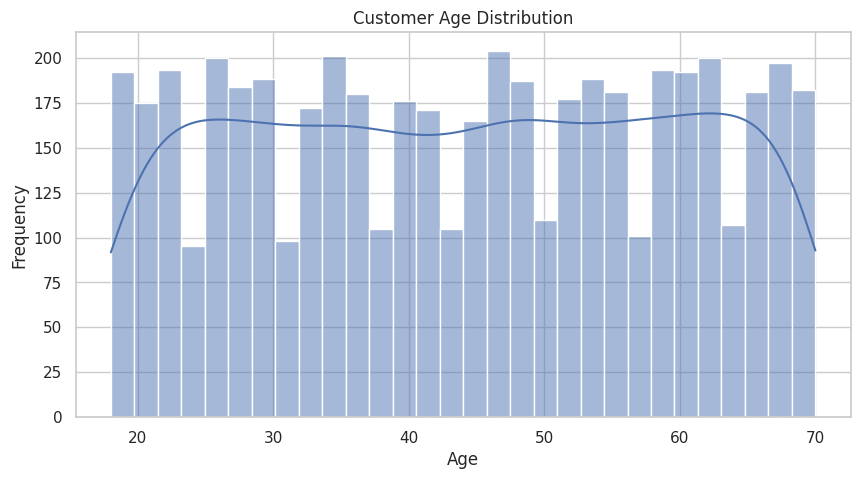

In [6]:
# Plot customer age distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['customer_age'], bins=30, kde=True)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

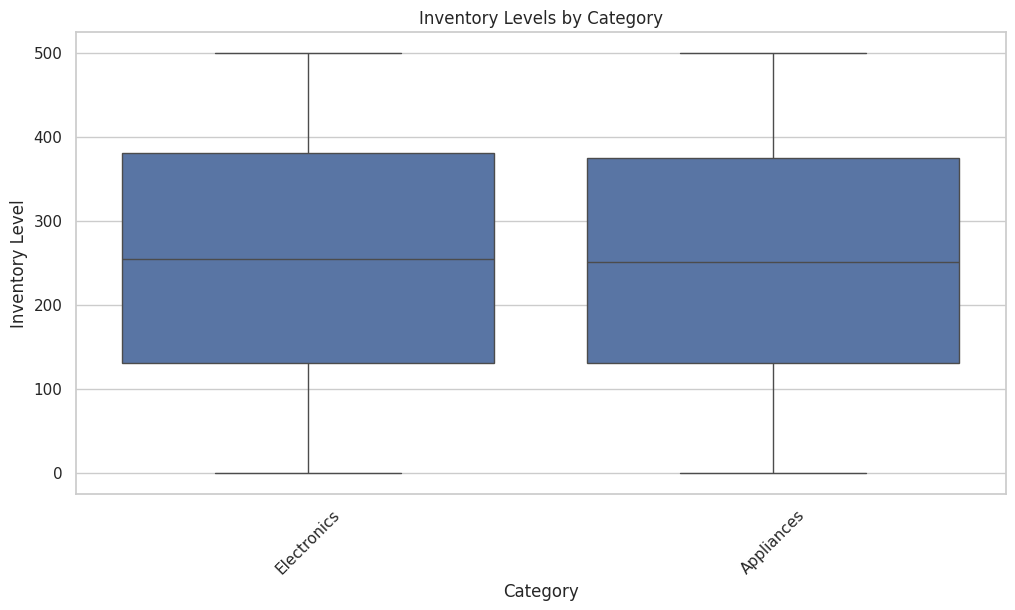

In [7]:
# Plot inventory levels by category
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='category', y='inventory_level')
plt.title('Inventory Levels by Category')
plt.xlabel('Category')
plt.ylabel('Inventory Level')
plt.xticks(rotation=45)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Select features and target variable
features = ['quantity_sold', 'unit_price', 'inventory_level', 'reorder_point', 'customer_age', 'customer_income']
target = 'forecasted_demand'

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Optionally, scale the features (important for certain models, but RandomForest is less sensitive to this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Evaluate the model using cross-validation
cross_val_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f'Cross-Validation Mean Squared Error: {-cross_val_scores.mean()}')

# Make predictions and evaluate the model on the test set
predictions = best_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Output the results
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Cross-Validation Mean Squared Error: 13611.225996421665
Mean Squared Error: 12747.629239155804
R-squared: -0.005762486058767502
